In [13]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("customer_segmentation_dataset.csv")

df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,56,52,80
1,2,46,38,2
2,3,32,83,92
3,4,25,130,32
4,5,38,112,91


In [6]:
print("Shape of data:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

Shape of data: (200, 4)

Data Types:
 CustomerID                int64
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Missing Values:
 CustomerID                0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary:
        CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000           200.00000              200.000000
mean   100.500000   38.665000            83.43000               47.865000
std     57.879185   12.604648            39.39945               28.626459
min      1.000000   18.000000            15.00000                1.000000
25%     50.750000   27.750000            48.75000               23.000000
50%    100.500000   40.000000            81.50000               45.000000
75%    150.250000   49.250000           117.25000               73.250000
max    200.000000   59.000000           149.00000             

In [7]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Rename columns (for easy use)
df.columns = ["CustomerID", "Age", "Income", "SpendingScore"]

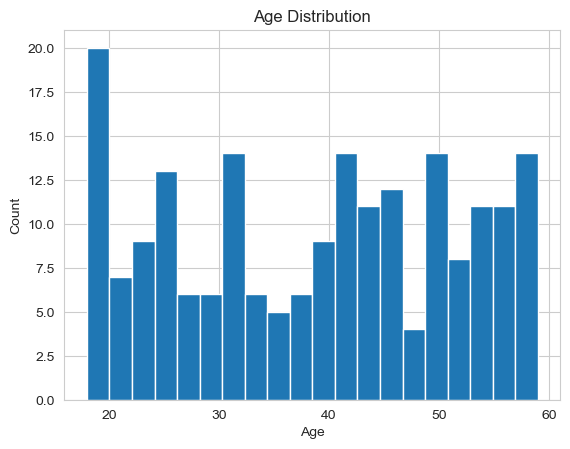

In [8]:
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

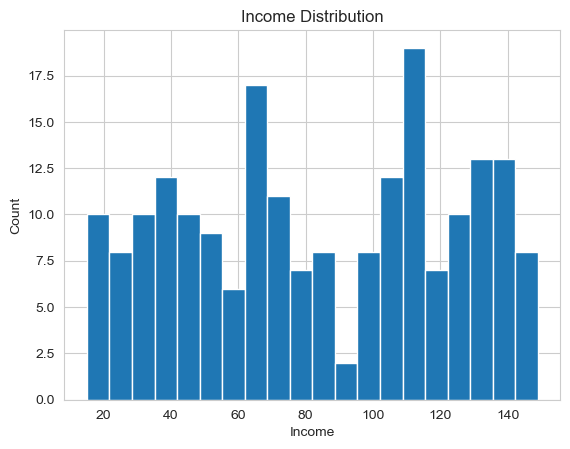

In [9]:
plt.hist(df["Income"], bins=20)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

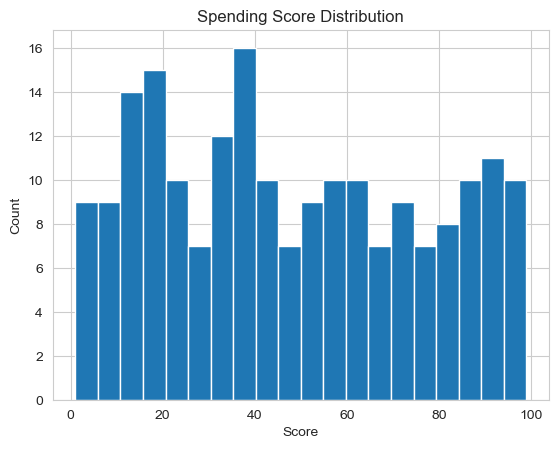

In [10]:
plt.hist(df["SpendingScore"], bins=20)
plt.title("Spending Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

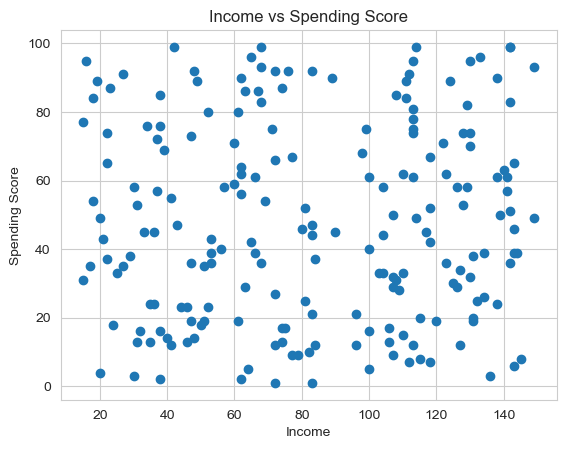

In [11]:
plt.scatter(df["Income"], df["SpendingScore"])
plt.title("Income vs Spending Score")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

In [14]:
from sklearn.cluster import KMeans

X = df[["Income", "SpendingScore"]]

kmeans = KMeans(n_clusters=5, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

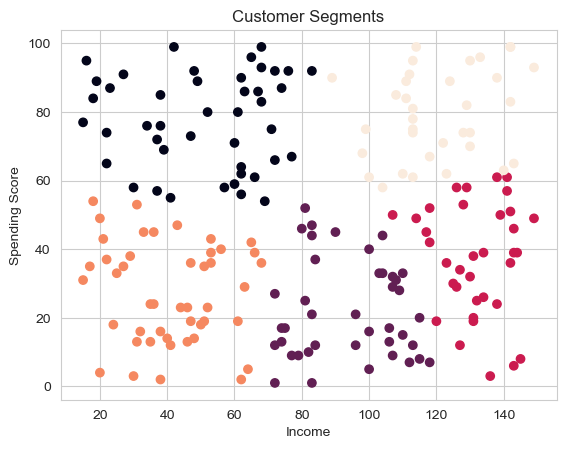

In [15]:
plt.scatter(df["Income"], df["SpendingScore"], c=df["Cluster"])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

In [16]:
cluster_summary = df.groupby("Cluster").mean()
print(cluster_summary)

         CustomerID        Age      Income  SpendingScore
Cluster                                                  
0        101.681818  41.681818   50.886364      77.545455
1        109.268293  39.073171   94.024390      22.195122
2         93.771429  35.171429  131.771429      37.028571
3        103.565217  38.565217   40.934783      27.326087
4         91.176471  38.000000  120.500000      79.352941


In [17]:
def label_segment(row):
    if row["Income"] > 80 and row["SpendingScore"] > 60:
        return "High Value"
    elif row["Income"] > 80 and row["SpendingScore"] < 40:
        return "Rich but Low Spending"
    elif row["Income"] < 40 and row["SpendingScore"] > 60:
        return "Budget High Spenders"
    else:
        return "Average Customers"

df["Segment"] = df.apply(label_segment, axis=1)

df["Segment"].value_counts()

Segment
Average Customers        105
Rich but Low Spending     46
High Value                36
Budget High Spenders      13
Name: count, dtype: int64

In [18]:
segment_analysis = df.groupby("Segment")[["Income", "SpendingScore"]].mean()
print(segment_analysis)

                           Income  SpendingScore
Segment                                         
Average Customers       63.638095      44.552381
Budget High Spenders    26.769231      80.000000
High Value             120.972222      79.277778
Rich but Low Spending  115.239130      21.760870


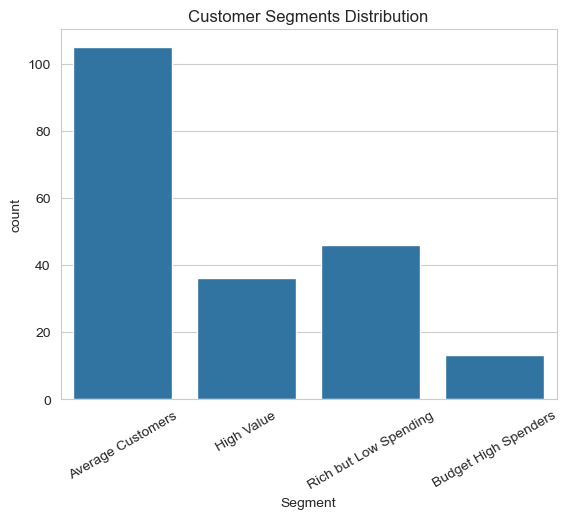

In [19]:
import seaborn as sns

sns.countplot(x="Segment", data=df)
plt.title("Customer Segments Distribution")
plt.xticks(rotation=30)
plt.show()

In [20]:
print("🔍 KEY INSIGHTS:\n")

print("1. Highest Income Group:")
print(df.groupby("Cluster")["Income"].mean().idxmax())

print("\n2. Highest Spending Group:")
print(df.groupby("Cluster")["SpendingScore"].mean().idxmax())

print("\n3. Segment Distribution:")
print(df["Segment"].value_counts())

print("\n4. Average Spending by Segment:")
print(df.groupby("Segment")["SpendingScore"].mean())

🔍 KEY INSIGHTS:

1. Highest Income Group:
2

2. Highest Spending Group:
4

3. Segment Distribution:
Segment
Average Customers        105
Rich but Low Spending     46
High Value                36
Budget High Spenders      13
Name: count, dtype: int64

4. Average Spending by Segment:
Segment
Average Customers        44.552381
Budget High Spenders     80.000000
High Value               79.277778
Rich but Low Spending    21.760870
Name: SpendingScore, dtype: float64


In [21]:
df.to_csv("final_customer_segments.csv", index=False)